#### Produce regulon plots for regulons that are increased in fetal state using ggplot

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
fetal_res_df = read.csv("04C_fetal_sig_regulon_df.csv")

#fetal_res_df$shortened_regulon <- sub("_.*", "", fetal_res_df$regulon)
fetal_res_df$log_padj <- -log10(fetal_res_df$padj)

In [3]:
# filter only to those cell-type specific regulons with mean AUC > 0.05
filtered_fetal_res_df <- fetal_res_df[fetal_res_df$AUC_mean_postnatal > 0.05, ]

In [4]:
#filtered_fetal_res_df <- filtered_fetal_res_df %>%
#  mutate(direction = ifelse(log2FC < 0, "negative", "positive"))

### Visualize regulons that have increased activity in fetal state

In [5]:
filt_positive_res_df <- filtered_fetal_res_df[filtered_fetal_res_df$log2FC > 0.25, ]

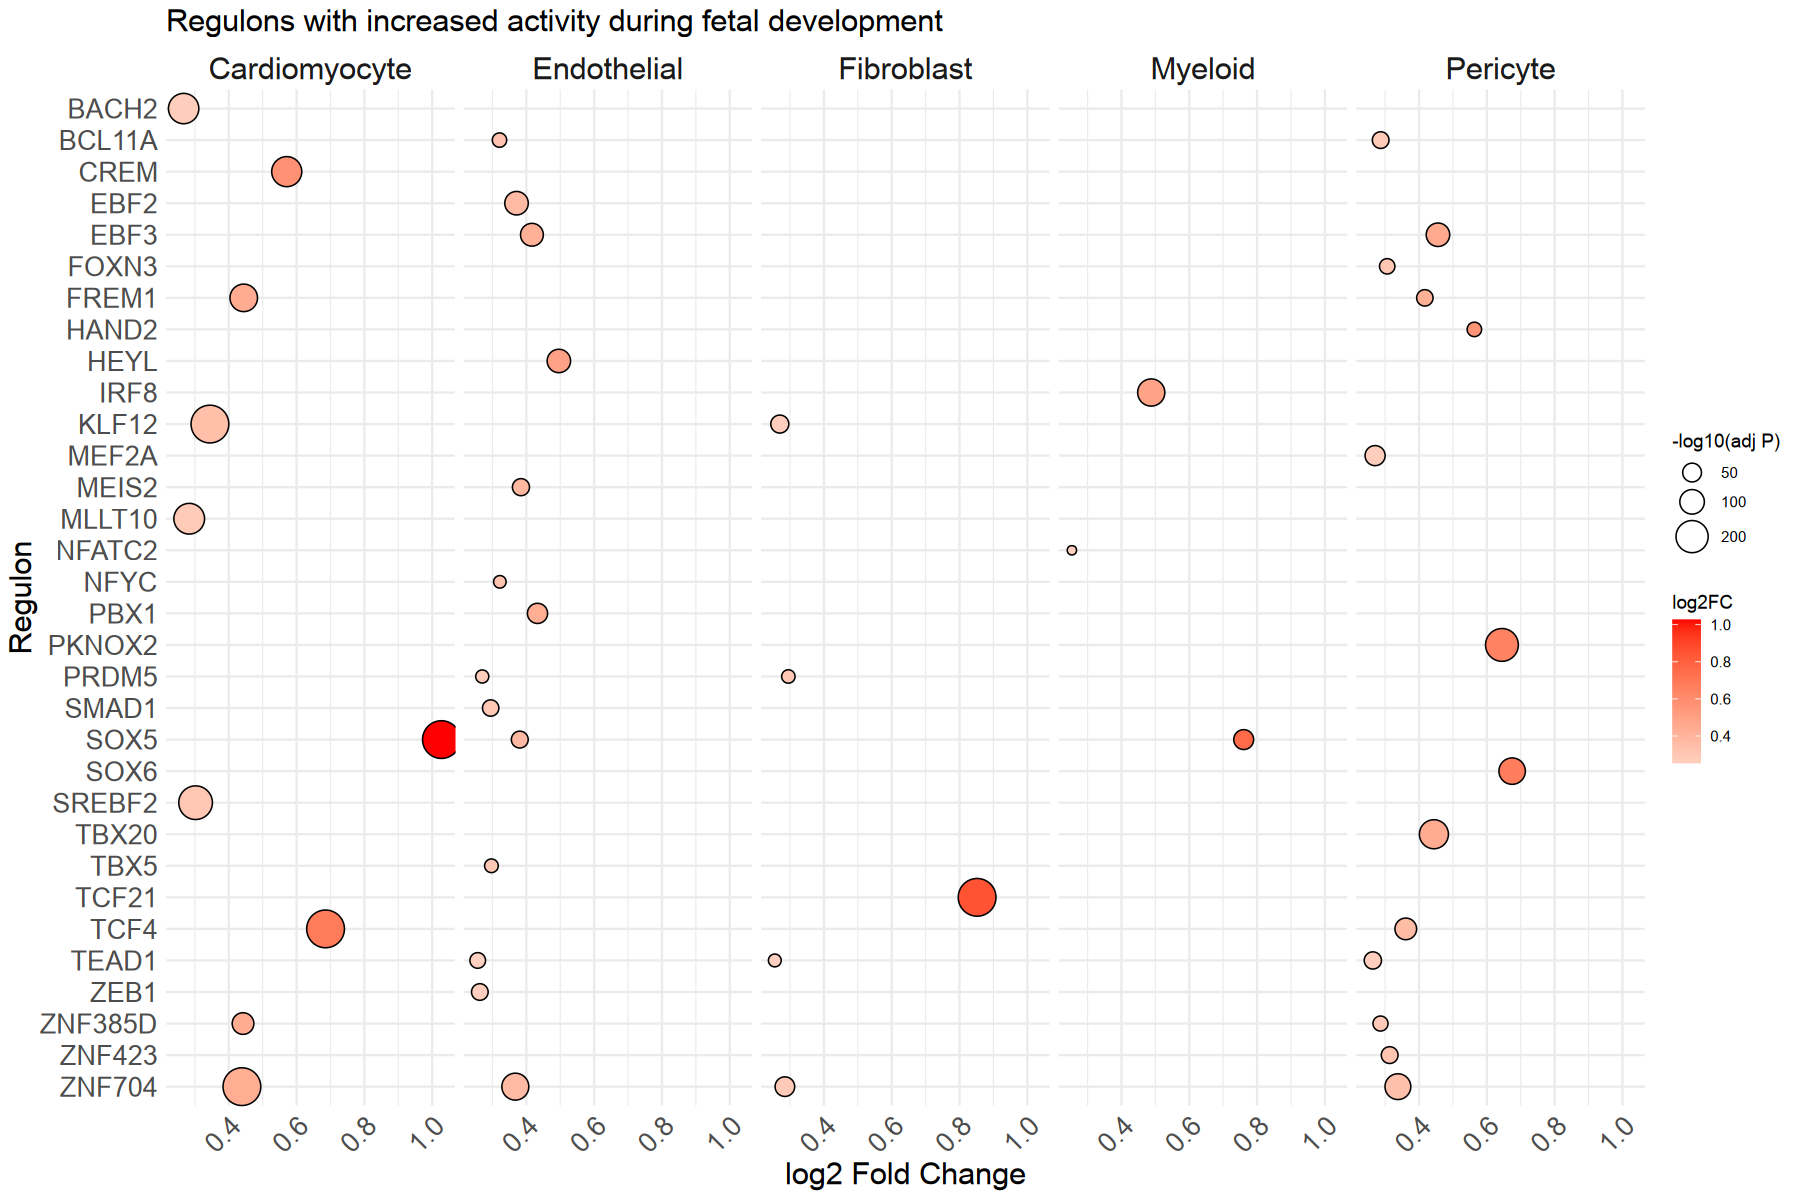

In [6]:
options(repr.plot.width = 15, repr.plot.height = 10)

filt_positive_res_df$regulon <- factor(filt_positive_res_df$regulon,
  levels = rev(sort(unique(filt_positive_res_df$regulon))) )

p1 <- ggplot(data = filt_positive_res_df, 
       mapping = aes(x = log2FC, y = regulon, size = log_padj, fill = log2FC)) +
  geom_point(shape = 21) + 
  facet_grid(~cell_type) + 
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, name = "log2FC") +
 scale_size_continuous(name = "-log10(adj P)", range = c(2, 10),
  breaks = sort(c(10, 50, 100, 200)), guide = guide_legend(reverse = FALSE)) +
  theme_minimal() +              
  theme(
    axis.text.y = element_text(size = 16),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),
    axis.title.y = element_text(size = 18), 
    axis.title.x = element_text(size = 18), 
    strip.text = element_text(face = "bold", size = 18),
    plot.title = element_text(size = 18),
    legend.position = "right") +
  labs(x = "log2 Fold Change", y = "Regulon", title = "Regulons with increased activity during fetal development")

p1 

ggsave(p1, filename = "04D_fetal_up_GRNs.pdf", height = 10, width = 15)

### Visualize regulons that have increased activity in postnatal state

In [7]:
filt_negative_res_df <- filtered_fetal_res_df[filtered_fetal_res_df$log2FC < -0.25, ]

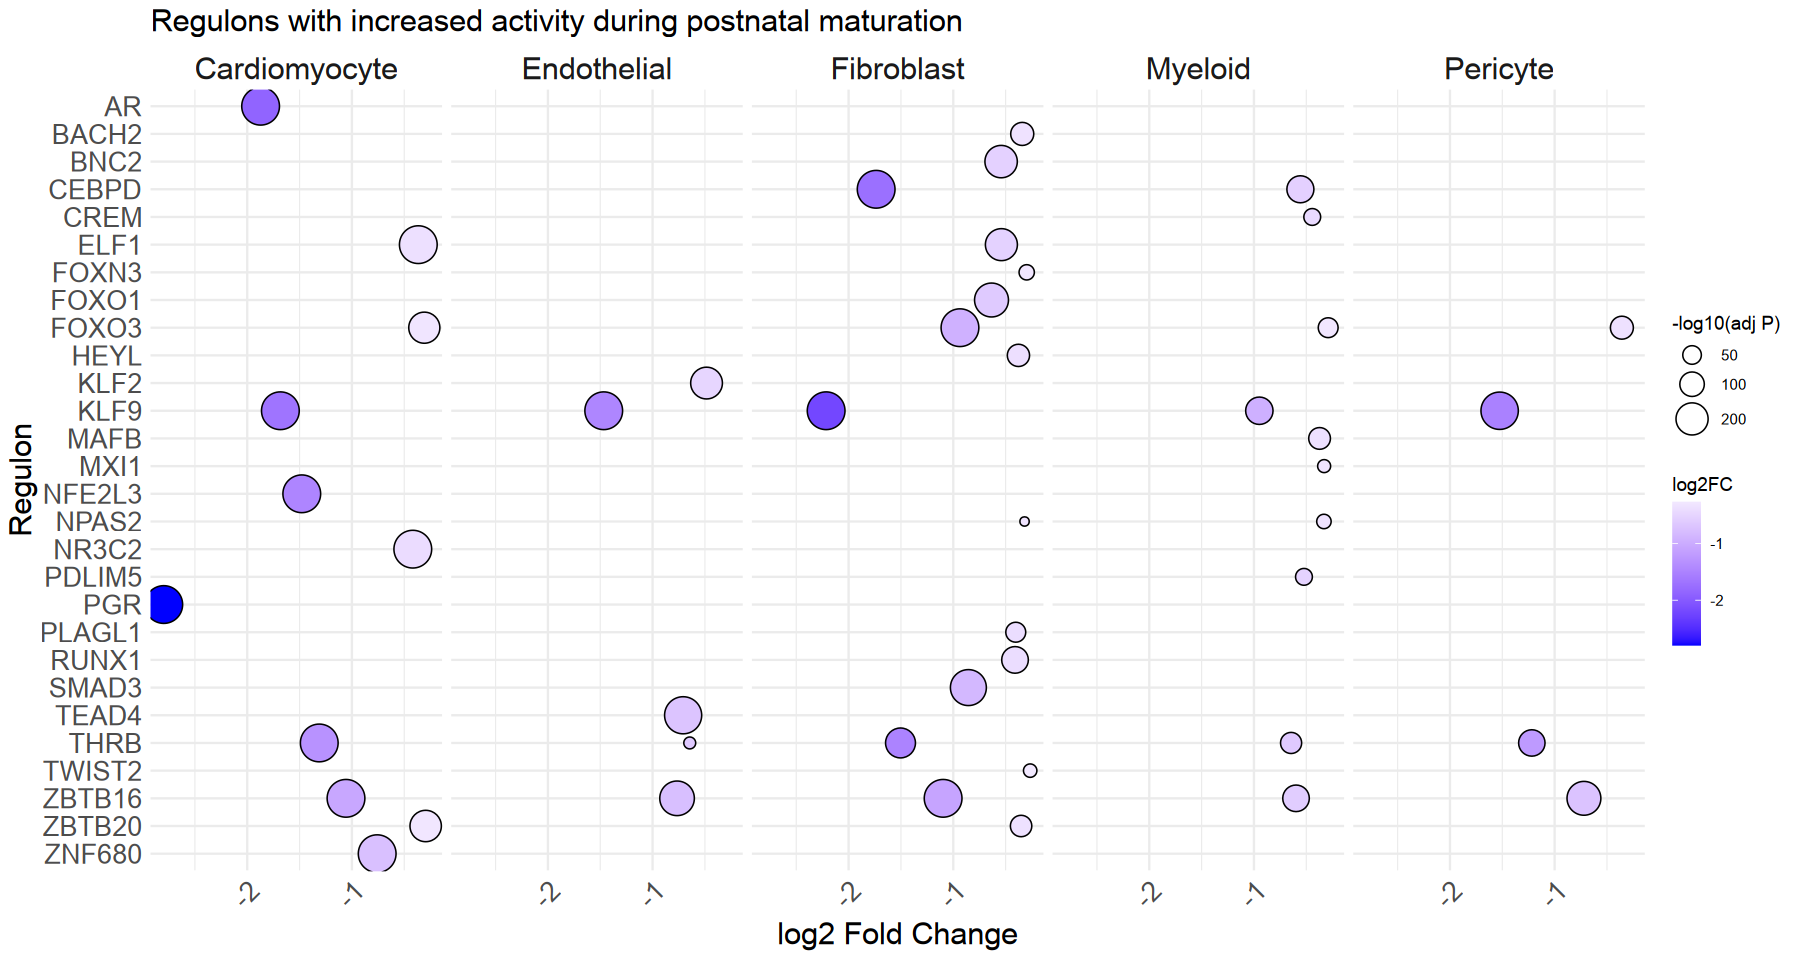

In [8]:
options(repr.plot.width = 15, repr.plot.height = 8)

filt_negative_res_df$regulon <- factor(
  filt_negative_res_df$regulon,
  levels = rev(sort(unique(filt_negative_res_df$regulon)))
)

p2 <- ggplot(data = filt_negative_res_df, 
       mapping = aes(x = log2FC, y = regulon, size = log_padj, fill = log2FC)) +
  geom_point(shape = 21) + 
  facet_grid(~cell_type) + 
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, name = "log2FC") +
   scale_size_continuous(name = "-log10(adj P)", range = c(2, 10),
  breaks = sort(c(10, 50, 100, 200)), guide = guide_legend(reverse = FALSE)) +
  theme_minimal() +              
  theme(
    axis.text.y = element_text(size = 16),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),
    axis.title.y = element_text(size = 18), 
    axis.title.x = element_text(size = 18), 
    strip.text = element_text(face = "bold", size = 18),
    plot.title = element_text(size = 18),
    legend.position = "right") +
  labs(x = "log2 Fold Change", y = "Regulon", title = "Regulons with increased activity during postnatal maturation")

ggsave(p2, filename = "04D_fetal_down_GRNs.pdf", height = 8, width = 15)

p2